# Lecture 3: Modern methods for SDEs

In this lecture we will start to add some things to what we set the last time. As we have noticed the last time, our method was quite problematic under the error POV due to the terrible order of magnitude of the cumulative error. In this lecture we aim to improve that results using some modern simulative approaches to minimize, where possible, the sources of error in the simulation. Moreover, we will treat a more complex system with many more bifurcations, although limited in its dimensionality of the parameters' space, using some automatic bifurcations tests. Nonetheless, we will not neglect the qualitative analysis aspect of the system.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
import random

## Exercise 1: Introducing the Stochastic Harvest Process

During this and the next lectures, we will work with the so called **Stochastic Harvest Process**. Blatantly, this comes from the deterministic process known as **Harvest Process** which is a variation of the logistic system:

**PROBLEM**: Let's consider a forest in which we have a normalized, upon the logistic carry value, amount of biomass $x$. The forest grows or shrinks accordingly to the logistic law. However this forest is not so uncontaminated by the human presence and some companies conducts lumberjack activities in the region cutting of a certain percentage of trees. So the equation for our deterministic problem is given by:

$$
\frac{dx}{dt}=a(x(1-x))-kx
$$

where $x$ is the normalized quantity of wood biomass, $a$ is a reinforcement parameter for the growth and $k$ is the intensity of the wood cutting activities in the region. To obtain the stochastic version, we suppose simply that the growing of the forest is not a deterministic phenomena but $a\rightarrow a+s\xi(t)$. With this we obtain the Ito's equation:

$$
dx = \left(a(x(1-x))-kx\right)dt+sx(1-x)dW
$$

This problem it has some inherited problems from the logistic. In particular in certain combinations will produce above 1 critical repulsors as we have seen for the logistic problem.

### Qualitative Analysis

The first thing we can do is, as before, doing some qualitative analysis. If we try to solve the usual expression for the critical points $f(x)\geq g(x)g'(x)$, we will find the following expresison:

$$
ax(1-x)-kx\geq s^2x(1-x)(1-2x) \quad\Rightarrow\quad a(1-x)-k\geq s^2(1-x)(1-2x)
$$

taking note that $x\geq0$ (so $x=0$ is critical independently by the parameters). Unfortunately, solving this inequality is quite complicate and the solution is very complex therefore it is almost impossible to understand the role of the parameters. We need here to perform some advanced qualitative analysis.

In such difficult situation the easiest thing is to start from the $s=0$. In the deterministic case we have as crticial points $x=0$ (repulsor) and $x=1-k/a$ (attractor). Due to sensitiveness, for now, let's consider the **first restriction**: $k/a<1$. Now we can expect that, if we start to move from $s=0$ increasing the noise, due to the continuity of the functions, we will have an initial neighbourhood of $s$ without bifurcations for which the SDE shares the number and the properties of the critical points of the ODE version.

Now our first objective is to understand where the bifurcations start to occur after this initial phase and what is the effect of the noise on the critical points. Starting from 0, which is easier, we have that 0 is critical for any combination of parameters. We can study the behaviour locally solving the inequality above. Doing it we will find that

$$
s\leq\sqrt{a-k}
$$

Thus given $x\rightarrow 0^+$, the field will suddenly become negative when $s$ raises above a certain value. In other terms. 0 is at the beggining a repulsor but for strong noises it becomes an attractor. We don't need extra conditions for the validity of the radix. Changing the behaviour of a critical point is important because a critical point cannot change its behaviour on their own. Staying in 0 there are only two possibilities: a transcritical bifurcation or a fork bifurcation.   

Talking about the upper critical point. We know that is the attractor of our system. Supposing to have $s>0$, we will have that, putting ourselves in $1-k/a$,

$$
0\geq s^2\frac{k}{a}\left(\frac{2k}{a}-1\right) \quad\Rightarrow\quad \frac{k}{a}\leq\frac{1}{2}
$$

This tells us some important things:

- Looking to the left we have that the right hand is not anymore 0. This means that $1-k/a$ is not a critical point for $s>0$; in other terms the critical point has moved to another position (being for any $s>0$ it is not possible for continuity to have a bifurcation).
- We have that the sign of the right hand depends from a new condition $k/a<1/2$ or, in other terms, $1/2<1-k/a<1$.
- If this condition is valid we have that the inequality is true thus the field in $1-k/a$ is positive and the critical point is moving to the right.
- If this condition is not valid we have that the inequality is false thus the field in $1-k/a$ is negative and the critical point is moving to the left.

Ok, we have understood the movement but how far they will move? is it $s^2$ dependent?. Answering the first question:

In the right-moving case, it is trivial to see that if $x>1$ the inequality is always false independently from the parameters thus it is impossible for the critical point to go over this value. However if we describe the new critical point as $x^*=1-(k/a)+\sigma$ we can find that:

$$
a\sigma\leq s^2\left(\sigma-\frac{k}{a}\right)\left(1+2\sigma-\frac{2k}{a}\right)
$$

where the last term is always negative for hypothesis and the immediately previous it is negative if $\sigma<k/a$ or in other term $x^*<1$. It is immediate that $\sigma\propto s^2$ thus as the noises increase the points moves towards 1.

In the left moving case, describing the critical point as $x^*=1-(k/a)-\sigma$ we can find that:

$$
a\sigma \geq s^2\left(\frac{k}{a}+\sigma\right)\left(\frac{2k}{a}+2\sigma-1\right)
$$

where the terms are always positive given the conditions. It is clear that $\sigma\propto s^2$. Thus is will tends towards 0. It is interesting that if we pose $x^*$ close to 0, we can approximate the critical point inequality as:

$$
a-k-s^2\geq x^*(a-3s^2) \quad\Rightarrow\quad x^*\leq \frac{a-k-s^2}{a-3s^2}
$$

Where the numerator becomes null for the same bifurcation value of $0$! Thus what's happening is that the upper critical point falls towards 0 and they have a transcritical bifurcation... there is one big problem: that the denominator must be positive! The condition at the numerator tells us that this is valid if $s^2\leq a/3$ thus we have a new condition... unfortunately. But what this implies? Let's remember that this formula, especially at the beginning when the critical point is quite far from 0, can also be interpreted as the local field tendency near 0.

First of all, if $s$ is small enough the field is positive thus our field is converging towards 0. Now it starts a sort of game of priority. If the denominator condition is valid before the numerator one we will have that the upper critical point will converge towards 0 and the field between the two point will stay positive. In the other case we will have that:

$$
\frac{a}{3}\leq a-k \quad\Rightarrow\quad  condition: \frac{1}{2}\leq\frac{k}{a}\leq \frac{2}{3}
$$

and the field locally negative because the fork bifurcation has take place before the converging of the upper point. Increasing $s$ the two point will have to meet to a certain point and most probably will produce a ghost bifurcation that will lead to the reciprocal cancellation with the production of a ghost critical point. 

So summing up:

- If $k/a<1/2$ also, we have that the upper tends to 1 staying attractor. $0$ will become also attractor after $s=\sqrt{a-k}$ with a fork bifurcation producing a repulsor between him and the upper attractor.
- If $k/a>2/3$ also, we have that the upper will converge towards 0. The two critical points will produce a transcritical bifurcation swapping their behaviour. For our domain we will have 0 as only attractor after this bifurcation.
- If $2/3>k/a>1/2$ also, we have that the upper will converge towards 0, BUT the fork bifurcation will take place before the transcritical bifurcation. The newly produce point will encounter the upper point for a certain $s$ and will produce a bifurcation; most probably a ghost bifurcation.

That's it, we are not forgetting anything..........

<img src="forgetting.jpg" alt="drawing" width="400"/> 

### Were there other ways?

This time the qualitative analysis was much complex than the previous lectures. We weren't even able to study the FP equation! There is a way to do it in an automatic numerical way? The answer is "yes but with some limits". The thing is that there is actually a very good method but there are some limitations of different types:

- **Analytical problems**: the method will use the $f(x)\geq g(x)g'(x)$. Sometimes writing this form can be difficult.
- **Human problems**: our brain cannot manage usually too well very high dimensional spaces. If the parameters are too much there will be some representation problems.
- **Structural problems**: the representation method is intuitive only with 1D or 2D systems.

The idea of the method is fairly simple: try to represent in which area the flows move towards the right and where it moves towards the left. This is simple because all of this information is contained in the inequality: we simply need to evaluate it.

Thus the things we need to do is to choose the parameters we want to vary, create a grid and evaluate it.

For our case let's choose from now on $a=1$ and vary only $k$ and $s$. If we want to study the first case we will set $k=0.3$ thus we expect the bifurcation at $s\approx 0.84$.

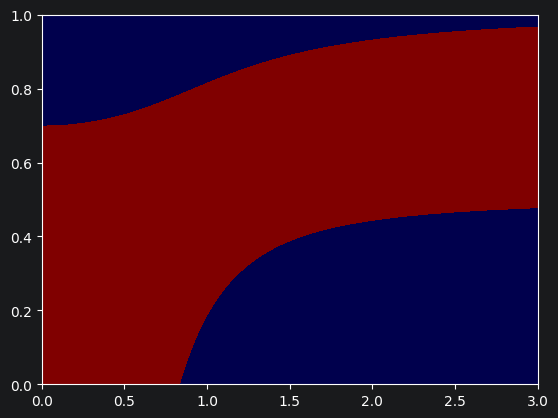

In [8]:
N = 5000 #THE NUMBER OF GRID POINTS
a_0 = 1.0
k = 0.3

x = np.linspace(0,1,N)
s = np.linspace(0,3.0,N)

values = np.zeros((N,N),dtype=float)

for i in range(len(x)):
    for j in range(len(s)):
        values[i,j] = a_0*(1-x[i])-k-s[j]*s[j]*(1-x[i])*(1-2*x[i])
        if values[i,j]>=0:
            values[i,j] = 1 #Moving to the right
        else:
            values[i,j] = -1 #Moving to the left

plt.pcolormesh(s,x,values,cmap="seismic") #RED: to the right, BLUE: to the left

As we can see we have exactly what we have predicted given our conditions. Let's see the other cases. For the second one we can take $k=0.7$

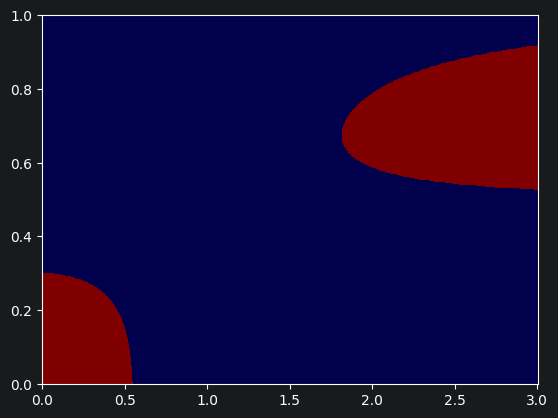

In [12]:
N = 500 #THE NUMBER OF GRID POINTS
a_0 = 1.0
k = 0.7

x = np.linspace(0,1,N)
s = np.linspace(0,3.0,N)

values = np.zeros((N,N),dtype=float)

for i in range(len(x)):
    for j in range(len(s)):
        values[i,j] = a_0*(1-x[i])-k-s[j]*s[j]*(1-x[i])*(1-2*x[i])
        if values[i,j]>=0:
            values[i,j] = 1 #Moving to the right
        else:
            values[i,j] = -1 #Moving to the left

plt.pcolormesh(s,x,values,cmap="seismic") #RED: to the right, BLUE: to the left

Wait... what is that red stain on the right? Let's see when $k<2/3$

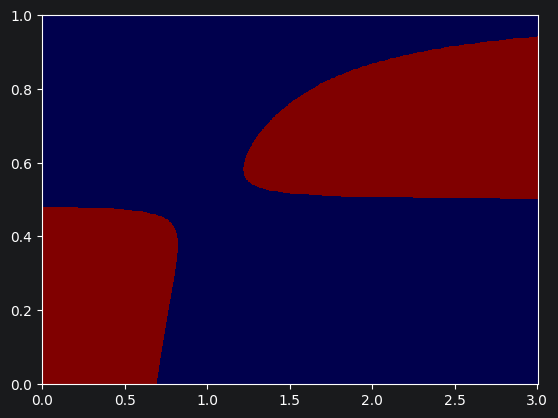

In [10]:
N = 500 #THE NUMBER OF GRID POINTS
a_0 = 1.0
k = 0.52

x = np.linspace(0,1,N)
s = np.linspace(0,3.0,N)

values = np.zeros((N,N),dtype=float)

for i in range(len(x)):
    for j in range(len(s)):
        values[i,j] = a_0*(1-x[i])-k-s[j]*s[j]*(1-x[i])*(1-2*x[i])
        if values[i,j]>=0:
            values[i,j] = 1 #Moving to the right
        else:
            values[i,j] = -1 #Moving to the left

plt.pcolormesh(s,x,values,cmap="seismic") #RED: to the right, BLUE: to the left

Ok, first things first. We can see the two different situation: in fact in the upper one we have the direct convergence while here we have the fork bifurcation and the encounter with the descending upper point. But what is that red stain? This is a typical problem when doing this kind of analysis. If you remember before we have neglected a particular case, for $k>1/2$, there is always a value when both the numerator and the nominator become once again positive. This is due to the creation of a new positive critical point! This is quite common phenomena but always difficult to predict exactly and easily forgettable. The reason is that the ghost bifurcation let to critical point disappear but the number of solution of the inequality stays the same but, as always, for certain parameters some coincide or simply moves out the domain of interest. This does not mean that a new critical point will be able to appear once again for sufficiently high value of a certain parameter. 

Ok we have spent too much time today on the qualitative analysis. Let's move to some simulative approaches

## Exercise 2: Milstein vs Maruyama

Last time, we have seen that, given a generic SDE in Ito's formula, we can:

$$
dx = f(x)dt + g(x)dW \quad\Rightarrow\quad x_{n+1}=x_n+f(x_n)h+g(x_n)\mathcal{N}(0,1)\sqrt{h}
$$

but this method has an error, due to the stochastic approximation, of $O(\sqrt{h})$ while the deterministic part is still contributing as $O(h)$ which is also not wonderful. In this part of the last part of the lecture we want to simulate the Stochastic Harvest Process but we would like at first to improve our method.

One of the most common solution is the **Milstein Method**. This method is an improvement of the Maruyama method and it simply add the next term of the series which, truncated, produced the Maruyama one. Applying this method we simulate the SDE as:

$$
x_{n+1} = x_n + f(x_n)h + g(x_n)\epsilon\sqrt{h} + \frac{1}{2}g(x_n)g'(x_n)h(\epsilon^2-1) \qquad\text{where}\quad \epsilon = \mathcal{N}(0,1)
$$

thus the idea is to generate a single gaussian number to use in two position. This method has a cumulative error of $O(h)$ both on the stochastic and the deterministic part. However this has a radical problem: the derivative. It is not a given fact the existence of the derivative or the fact that it has a simple or an analytical expression at all. The second is somehow solvable approximating the derivative using some numerical method with cumulative error of order small than $O(h)$ but the first one it is required for the validity of the method in general. 

For the Harvest Process the situation is quite simple thus we can implement the Milstein Method using the derivative:

$$
g(x)' = s(1-2x)
$$

To implement the method we can simply take the code of the last time and modify it

In [13]:
class Harvest(object):

    #CONSTRUCTOR:
    def __init__(self,a: float,k: float,s: float)->None:
        #First let's check the inputs
        if(a<0 or k<0 or s<0):
            raise RuntimeError("The system parameters must be non-negative.")

        self._a = a
        self._k = k
        self._s = s
        return

    #This function is used to change the value of the params between a iteration and another
    def setParam(self,a: float,k: float,s: float)->None:
        '''
        This function recieve new values for the parameters (a,k,s)
        and, after some checks, use them as new params of the Harvest Process.
        '''
        if(a<0 or k<0 or s<0):
            raise RuntimeError("The system parameters must be non-negative.")

        self._a = a
        self._k = k
        self._s = s
        return
        
    #This function will produce a realization/trajectory for the system
    #using the Milstein discretization.
    def computeTraj(self,n_step: int,h: float,x0: float)->np.array:
        '''
        Given the number of step, the step length and the initial condition,
        this function will produce a trajectory using the Milstein method.
        '''

        #1. Perform some check of the arguments:
        if(n_step<0):
            raise RuntimeError("The number of step must be non-negative.")
        if(h<=0):
            raise RuntimeError("Step size must be positive.")
        if(x0<0):
            raise RuntimeError("The initial size of the population must be non negative.")

        #2. Now we can set the output and start simulate
        traj = np.zeros(n_step+1,dtype=float)
        traj[0] = x0

        for i in range(1,n_step+1):
            traj[i] = traj[i-1]+(self._a*(1-traj[i-1])-self._k)*traj[i-1]*h #DETERMINISTIC PART
            eps = random.gauss(0,1)
            traj[i] += self._s*traj[i-1]*(1-traj[i-1])*np.sqrt(h)*eps #FIRST STOCHASTIC TERM
            traj[i] += 0.5*(self._s*traj[i-1]*(1-traj[i-1]))*(self._s*(1-2*traj[i-1]))*h*(eps*eps-1)

        return traj

Kanpeki! We can start to test if this works producing a trajectory. Using $(a,k,s)=(1.0,0.3,0.1)$. We should have the distribution centered around the upper attractor point.

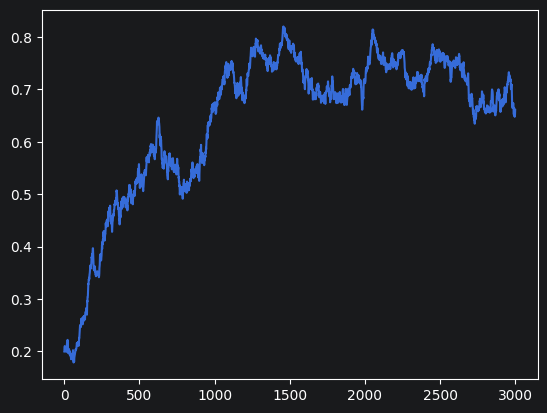

In [14]:
system = Harvest(1.0,0.3,0.25)

t = system.computeTraj(3000,0.01,0.2)

plt.plot(t)

Before starting to produce distribution and perform some tests, I would like to introduce some further improvements that one can use to improve the error and the quality of the trajectories

## Exercise 3: Runge-Kutta 4 and Splitting

Let's go back for a minute to the deterministic case. Given a generic ordinary differential equation (or equivalently a system of degree 1 ODEs) there are several method to simulate it. The Euler-Maruyama method we have seen for the SDE descends from the most simple of this deterministic algorithm: the Euler method:

$$
x'(t)=f(x,t) \quad\Rightarrow\quad x_{n+1}=x_n+h\cdot f(x_n,t_n)
$$

As said, this method has an awful cumulative error of $O(h)$ which is also multiplied for a constant depending on the regularity of the field. However there are several better methods to simulate the trajectory. One of the most common method is a variation of the Runge-Kutta method that is called Runge-Kutta4 or RK4. A variant (a sort of RK6) of this method is used by the most famous multilanguage ODE library (*odeint*). The RK4 method is base on computing 4 coefficient:

$$
\begin{align}
k_1=f(x_n,t_n) & \qquad k_2=f(x_n+h\frac{k_1}{2},t_n+\frac{h}{2})\\
k_3=f(x_n+h\frac{k_2}{2},t_n+\frac{h}{2})& \qquad k_4=f(x_n+hk_3,t_n+h)
\end{align}
$$

With this coefficient we can estimate the next point as:

$$
x_{n+1}=x_n+\frac{h}{6}\left(k_1+2k_2+2k_3+k_4\right)
$$

This method as a cumulative order of $O(h^4)$ which is incredibly good in comparison with the Euler method!

Now we would like to improve the error of our simulations. Before continuing I want to break your dreams: we will not be ablt to improve the error globally but what we can do it to minimize every other source of error leaving only the stochastic error. Under certain point of view this seems not radical because the total error will stay at the same order of the stochastic method but the order is not everthing. We can have several contribution and if the error of the stochastic part is $3h$ while the deterministic has an error of $500h$, the order will be $h$ but there is actually a radical difference on the total error. 

Therefore, we would like to improve the error on the deterministic part. It would be nice to simulate using different methods the different part of the equation! Luckly this is possible and this approach is called **Splitting**. The splitting is also possible for ODE but this approach is usable only when the ODE can be written as:

$$
x'(t)=f(x,t)+g(x,t)
$$

In the SDE is always possible because in the Ito expression we have always the sum of two terms. So we will apply a different numerical method to each one of the two terms to minimize the error. Therefore, as example, given $dx=f(x)dt+g(x)dW$ we can write the discretization as

$$
x_{n+1}=x_n+RK4(x_n,t_n)+MilsteinStochasticPart(x_n,t_n)
$$

This method is actually correct and it is the most naive way to perform the splitting. The order of the error here will be the one of the Milstein because the RK4 eliminates practically the deterministic contribution. However this is not the only possible splitting approach. One of th most common is the Strang Splitting method that allows some good improvements not in the order of magnitude but more in the multiplicative constant. For the sake of this course we will use the naive.

Ok thus we can implement the RK4 method in our code!

In [15]:
class Harvest(object):

    #CONSTRUCTOR:
    def __init__(self,a: float,k: float,s: float)->None:
        #First let's check the inputs
        if(a<0 or k<0 or s<0):
            raise RuntimeError("The system parameters must be non-negative.")

        self._a = a
        self._k = k
        self._s = s
        return

    #This function is used to change the value of the params between a iteration and another
    def setParam(self,a: float,k: float,s: float)->None:
        '''
        This function recieve new values for the parameters (a,k,s)
        and, after some checks, use them as new params of the Harvest Process.
        '''
        if(a<0 or k<0 or s<0):
            raise RuntimeError("The system parameters must be non-negative.")

        self._a = a
        self._k = k
        self._s = s
        return

    #This function will be used to evolve the deterministic part of the field
    #using Runge-Kutta4
    def __RK4(self,t_n: float,y_n: float,h: float)->float: 
        '''
        Given a point in the trajectory, the time instant and the step lenght,
        this method will compute the variation for y using the RK4 for the 
        deterministic part of the PLS
        '''

        f = lambda x: self._a*x*(1-x)-self._k*x
        
        k_1 = f(y_n)
        k_2 = f(y_n+h*k_1/2)
        k_3 = f(y_n+h*k_2/2)
        k_4 = f(y_n+h*k_3)

        return h*(k_1+2*k_2+2*k_3+k_4)/6
        
    #This function will produce a realization/trajectory for the system
    #using the Milstein discretization.
    def computeTraj(self,n_step: int,h: float,x0: float)->np.array:
        '''
        Given the number of step, the step length and the initial condition,
        this function will produce a trajectory using the Milstein method.
        '''

        #1. Perform some check of the arguments:
        if(n_step<0):
            raise RuntimeError("The number of step must be non-negative.")
        if(h<=0):
            raise RuntimeError("Step size must be positive.")
        if(x0<0):
            raise RuntimeError("The initial size of the population must be non negative.")

        #2. Now we can set the output and start simulate
        traj = np.zeros(n_step+1,dtype=float)
        traj[0] = x0

        for i in range(1,n_step+1):
            traj[i] = traj[i-1]+self.__RK4(i*h,traj[i-1],h) #DETERMINISTIC PART
            eps = random.gauss(0,1)
            traj[i] += self._s*traj[i-1]*(1-traj[i-1])*np.sqrt(h)*eps #FIRST STOCHASTIC TERM
            traj[i] += 0.5*(self._s*traj[i-1]*(1-traj[i-1]))*(self._s*(1-2*traj[i-1]))*h*(eps*eps-1)

        return traj

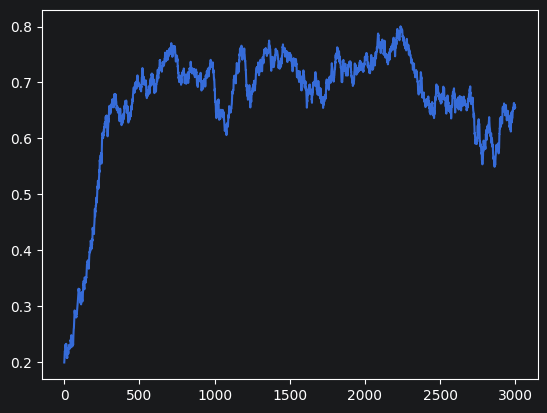

In [16]:
system = Harvest(1.0,0.3,0.25)

t = system.computeTraj(3000,0.01,0.2)

plt.plot(t)

Everything works! The next lecture we will start to simulate this system, we will try to find some possible automatic tests and discovers some sources of meta-errors that does not depends by our methods.